100%|██████████| 1.49G/1.49G [00:23<00:00, 67.9MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/kwentar/blur-dataset/versions/2
defocused_blurred: 350 images
motion_blurred: 350 images
sharp: 350 images
-----------------------------------
Total images : 1050
Blur  images : 700
Sharp images : 350
Image shape  : (256, 256)
-----------------------------------


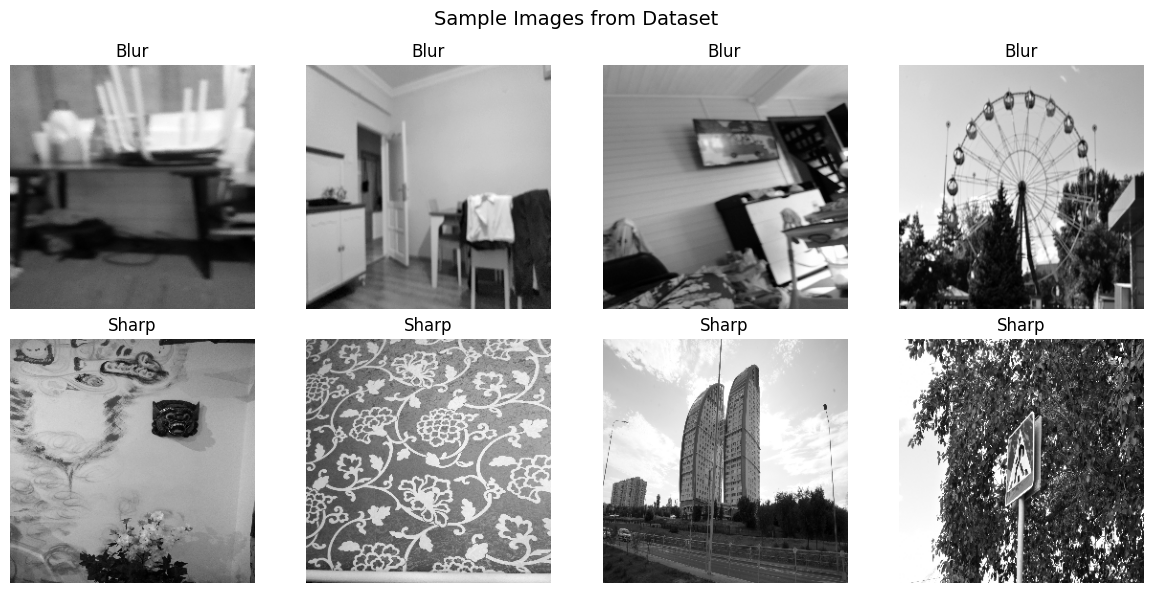

In [ ]:
import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Load Dataset from Kaggle
# ------------------------------
path = kagglehub.dataset_download("kwentar/blur-dataset")
print("Dataset path:", path)


BLUR_DIRS = [
    os.path.join(path, 'defocused_blurred'),
    os.path.join(path, 'motion_blurred')
]
SHARP_DIR = os.path.join(path, 'sharp')

# -----------------------------
#Load Function
# -----------------------------
def load_dataset(blur_dirs, sharp_dir, img_size=(256, 256)):
    images, labels = [], []

    # Load Blur (label = 0)
    for blur_dir in blur_dirs:
        files = os.listdir(blur_dir)
        print(f"{os.path.basename(blur_dir)}: {len(files)} images")

        for img_name in files:
            img_path = os.path.join(blur_dir, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, img_size)
                images.append(img)
                labels.append(0)  # 0 = blur

    # Load Sharp (label = 1)
    files = os.listdir(sharp_dir)
    print(f"sharp: {len(files)} images")

    for img_name in files:
        img_path = os.path.join(sharp_dir, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            img = cv2.resize(img, img_size)
            images.append(img)
            labels.append(1)  # 1 = sharp

    return np.array(images), np.array(labels)

# -----------------------------
# Run the program
# -----------------------------
images, labels = load_dataset(BLUR_DIRS, SHARP_DIR)

# ------------------------------
# statistic
# ------------------------------
print("-" * 35)
print(f"Total images : {len(images)}")
print(f"Blur  images : {np.sum(labels == 0)}")
print(f"Sharp images : {np.sum(labels == 1)}")
print(f"Image shape  : {images[0].shape}")
print("-" * 35)

# -----------------------------
# View sample images
# ----------------------------
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

blur_idx  = np.where(labels == 0)[0][:4]
sharp_idx = np.where(labels == 1)[0][:4]

for i, idx in enumerate(blur_idx):
    axes[0, i].imshow(images[idx], cmap='gray')
    axes[0, i].set_title('Blur')
    axes[0, i].axis('off')

for i, idx in enumerate(sharp_idx):
    axes[1, i].imshow(images[idx], cmap='gray')
    axes[1, i].set_title('Sharp')
    axes[1, i].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# **Feature Extraction**

In [ ]:
from scipy.stats import entropy as shannon_entropy

# ------------------------------
#  Features
# ------------------------------

# Feature 1: Laplacian Variance
def laplacian_variance(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

# Feature 2: Edge Density
def edge_density(img):
    edges = cv2.Canny(img, 100, 200)
    return np.sum(edges > 0) / edges.size

# Feature 3 & 4: Gradient Mean + Std
def gradient_features(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx**2 + gy**2)
    return magnitude.mean(), magnitude.std()

# Feature 5: Tenengrad
def tenengrad(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1)
    return np.mean(gx**2 + gy**2)

# Feature 6: FFT High Frequency Energy
def fft_high_freq(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    mag = np.abs(fshift)
    h, w = img.shape
    cy, cx = h//2, w//2
    r = min(h, w)//8
    low = mag[cy-r:cy+r, cx-r:cx+r].sum()
    return 1 - (low / mag.sum())

# -----------------------------
# Function to group all features
# -----------------------------
def extract_features(img):
    grad_mean, grad_std = gradient_features(img)
    return [
        laplacian_variance(img),   # Feature 1
        edge_density(img),         # Feature 2
        grad_mean,                 # Feature 3
        grad_std,                  # Feature 4
        tenengrad(img),            # Feature 5
        fft_high_freq(img),        # Feature 6
    ]

# -----------------------------
# Implementation to all images
# -----------------------------
print("Extracting features...")
X = np.array([extract_features(img) for img in images])
y = np.array(labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape        : {y.shape}")


import pandas as pd

feature_names = [
    'Laplacian Var', 'Edge Density',
    'Gradient Mean', 'Gradient Std',
    'Tenengrad',     'FFT High Freq'
]

df = pd.DataFrame(X, columns=feature_names)
df['Label'] = ['Blur' if l == 0 else 'Sharp' for l in y]

print("\n Feature Statistics:")
print(df.groupby('Label').mean().round(4))

Extracting features...
Feature matrix shape: (1050, 6)
Labels shape        : (1050,)

 Feature Statistics:
       Laplacian Var  Edge Density  Gradient Mean  Gradient Std   Tenengrad  \
Label                                                                         
Blur        389.5486        0.0479        43.3409       58.8950   6432.1925   
Sharp      3462.9727        0.1125        72.2924       98.8098  17191.0685   

       FFT High Freq  
Label                 
Blur          0.4475  
Sharp         0.6687  


Features scaled successfully

 Dataset Split:
----------------------------------------
Train :  735 images | Blur: 490 | Sharp: 245
Val   :  157 images | Blur: 105 | Sharp:  52
Test  :  158 images | Blur: 105 | Sharp:  53
----------------------------------------
Total : 1050 images


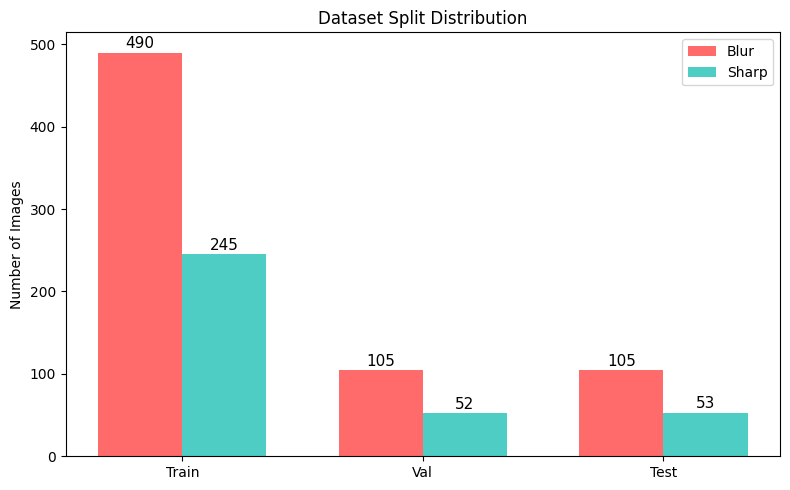

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# ----------------------------
# Features normalization
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for the demo later
joblib.dump(scaler, 'scaler.pkl')
print("Features scaled successfully")

# -----------------------------
# Split data
# ----------------------------
# First division: 70% Train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second division: The 30% is divided in half.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("\n Dataset Split:")
print(f"{'-'*40}")
print(f"Train : {len(X_train):4d} images | Blur: {sum(y_train==0):3d} | Sharp: {sum(y_train==1):3d}")
print(f"Val   : {len(X_val):4d} images | Blur: {sum(y_val==0):3d} | Sharp: {sum(y_val==1):3d}")
print(f"Test  : {len(X_test):4d} images | Blur: {sum(y_test==0):3d} | Sharp: {sum(y_test==1):3d}")
print(f"{'-'*40}")
print(f"Total : {len(X_train)+len(X_val)+len(X_test):4d} images")

# ------------------------------
# Visualization
# ------------------------------
import matplotlib.pyplot as plt

splits = ['Train', 'Val', 'Test']
blur_counts  = [sum(y_train==0), sum(y_val==0), sum(y_test==0)]
sharp_counts = [sum(y_train==1), sum(y_val==1), sum(y_test==1)]

x = range(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], blur_counts,  width, label='Blur',  color='#FF6B6B')
bars2 = ax.bar([i + width/2 for i in x], sharp_counts, width, label='Sharp', color='#4ECDC4')


for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(int(bar.get_height())),
            ha='center', fontsize=11)

ax.set_xticks(list(x))
ax.set_xticklabels(splits)
ax.set_ylabel('Number of Images')
ax.set_title('Dataset Split Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# -----------------------------
# GPU verification
# -----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ------------------------------
# MLP
# ------------------------------
class BlurClassifier(nn.Module):
    def __init__(self, input_size=6):
        super().__init__()
        self.network = nn.Sequential(
            # Hidden Layer 1
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 2
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output Layer
            nn.Linear(32, 1)
            # Sigmoid is not included here because BCEWithLogitsLoss handles it automatically.
        )

    def forward(self, x):
        return self.network(x)

# ------------------------------
# Preparing the Model
# ------------------------------
model = BlurClassifier(input_size=6).to(device)

# -----------------------------
# Loss with Class Weight
# ----------------------------
# Blur=700, Sharp=350 → We give Sharp a larger weight
pos_weight = torch.tensor([700/350]).to(device)  # = 2.0
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ------------------------------
# Optimizer
# ------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# Converting data to Tensors
# ----------------------------
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)

X_val_t   = torch.FloatTensor(X_val).to(device)
y_val_t   = torch.FloatTensor(y_val).unsqueeze(1).to(device)

X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# ------------------------------
# DataLoader
# -----------------------------
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

# ------------------------------
# Model Architecture
# ------------------------------
print("\n Model Architecture:")
print("-"*40)
print(model)
print("-"*40)

#Number of Parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\n Total Parameters: {total_params}")
print(f"Class Weight (Sharp): {pos_weight.item():.1f}x")



Using device: cpu

 Model Architecture:
----------------------------------------
BlurClassifier(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
----------------------------------------

 Total Parameters: 2561
Class Weight (Sharp): 2.0x


Training Started...
------------------------------------------------------------
Epoch  10/100 | Train Loss: 0.2345 | Val Loss: 0.2422 | Train Acc: 93.47% | Val Acc: 92.99%
Epoch  20/100 | Train Loss: 0.2087 | Val Loss: 0.2342 | Train Acc: 94.28% | Val Acc: 93.63%
Epoch  30/100 | Train Loss: 0.1953 | Val Loss: 0.2312 | Train Acc: 95.50% | Val Acc: 94.27%
Epoch  40/100 | Train Loss: 0.1720 | Val Loss: 0.2284 | Train Acc: 95.23% | Val Acc: 93.63%
Epoch  50/100 | Train Loss: 0.1690 | Val Loss: 0.2171 | Train Acc: 94.84% | Val Acc: 93.63%
Epoch  60/100 | Train Loss: 0.1863 | Val Loss: 0.2164 | Train Acc: 94.83% | Val Acc: 93.63%
Epoch  70/100 | Train Loss: 0.1668 | Val Loss: 0.2121 | Train Acc: 95.37% | Val Acc: 92.99%
Epoch  80/100 | Train Loss: 0.1688 | Val Loss: 0.2147 | Train Acc: 95.52% | Val Acc: 93.63%
Epoch  90/100 | Train Loss: 0.1583 | Val Loss: 0.2060 | Train Acc: 95.37% | Val Acc: 94.27%
Epoch 100/100 | Train Loss: 0.1520 | Val Loss: 0.2009 | Train Acc: 95.64% | Val Acc: 94.27%

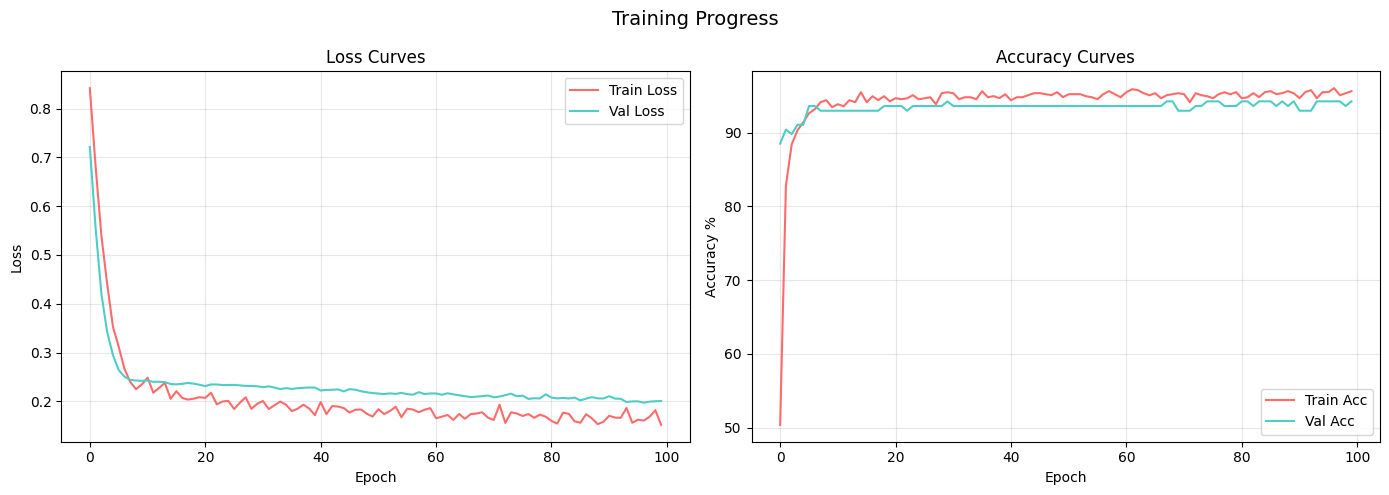

Model saved successfully!


In [ ]:
# ------------------------------
# Training Loop
# ------------------------------
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

EPOCHS = 100

print("Training Started...")
print("-"*60)

for epoch in range(EPOCHS):
    # ----------------------------
    # Train
    # ----------------------------
    model.train()
    batch_losses, batch_accs = [], []

    for X_batch, y_batch in train_loader:
        # Forward
        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)

        # Backward
        loss.backward()
        optimizer.step()

        # Accuracy
        preds = (torch.sigmoid(output) > 0.5).float()
        acc   = (preds == y_batch).float().mean()

        batch_losses.append(loss.item())
        batch_accs.append(acc.item())

    # ----------------------------
    # Validation
    # ----------------------------
    model.eval()
    with torch.no_grad():
        val_output = model(X_val_t)
        val_loss   = criterion(val_output, y_val_t).item()

        val_preds  = (torch.sigmoid(val_output) > 0.5).float()
        val_acc    = (val_preds == y_val_t).float().mean().item()


    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss)
    train_accs.append(np.mean(batch_accs))
    val_accs.append(val_acc)

    # Print every 10 epochs
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_accs[-1]*100:.2f}% | "
              f"Val Acc: {val_acc*100:.2f}%")

print("-"*60)
print("Training Complete!")

# -----------------------------
# Results
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
ax1.plot(train_losses, label='Train Loss', color='#FF6B6B')
ax1.plot(val_losses,   label='Val Loss',   color='#4ECDC4')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy Curves
ax2.plot([a*100 for a in train_accs], label='Train Acc', color='#FF6B6B')
ax2.plot([a*100 for a in val_accs],   label='Val Acc',   color='#4ECDC4')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training Progress', fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------
# Save the model
# ------------------------------
torch.save(model.state_dict(), 'blur_classifier.pth')
print("Model saved successfully!")

----------------------------------------
Test Accuracy: 93.04%
----------------------------------------

 Classification Report:
              precision    recall  f1-score   support

        Blur       0.99      0.90      0.95       105
       Sharp       0.84      0.98      0.90        53

    accuracy                           0.93       158
   macro avg       0.91      0.94      0.92       158
weighted avg       0.94      0.93      0.93       158



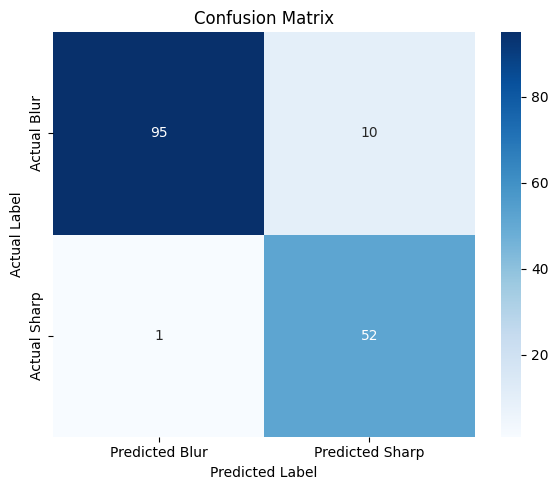

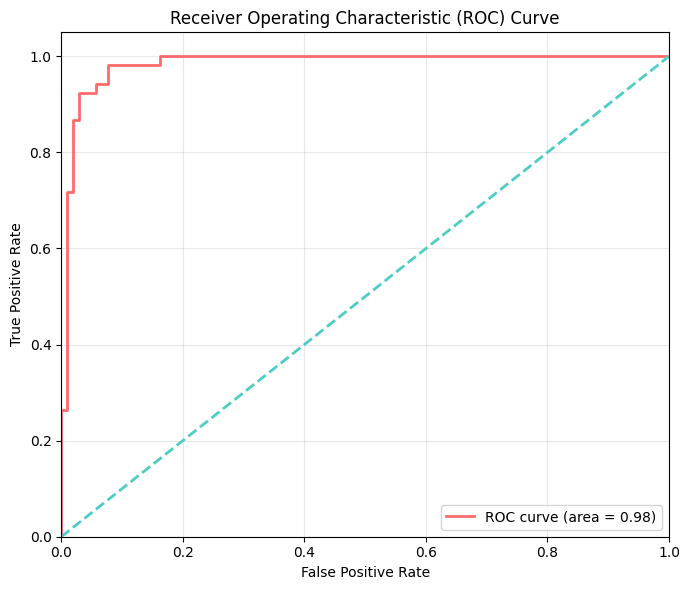

In [ ]:
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import seaborn as sns

# ------------------------------
# Evaluate the test
# -----------------------------
model.eval()
with torch.no_grad():
    test_output = model(X_test_t)
    test_probs  = torch.sigmoid(test_output).numpy().flatten()
    test_preds  = (test_probs > 0.5).astype(int)

# -----------------------------
# Actual result
# -----------------------------
acc = accuracy_score(y_test, test_preds)
print("-"*40)
print(f"Test Accuracy: {acc*100:.2f}%")
print("-"*40)

print("\n Classification Report:")
print(classification_report(y_test, test_preds, target_names=['Blur', 'Sharp']))

# ------------------------------
#  Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Blur', 'Predicted Sharp'],
            yticklabels=['Actual Blur', 'Actual Sharp'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ------------------------------
#  ROC Curve
# ------------------------------
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#FF6B6B', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='#4ECDC4', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Demo - Testing on sample images

Testing Blur Image:


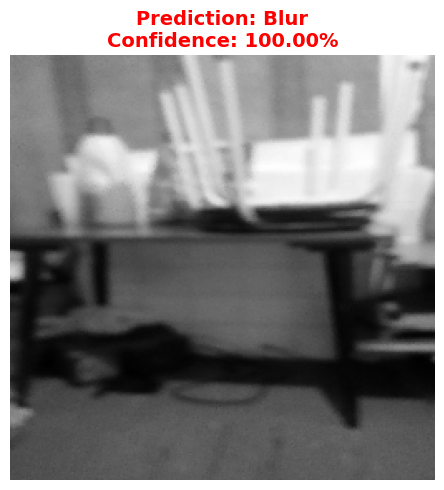


----------------------------------------
Result     : Blur
Confidence : 100.00%
----------------------------------------

Feature Values:
   Laplacian Var  : 102.8858
   Edge Density   : 0.0190
   Gradient Mean  : 35.2308
   Gradient Std   : 42.3972
   Tenengrad      : 3038.7295
   FFT High Freq  : 0.3737

Testing Sharp Image:


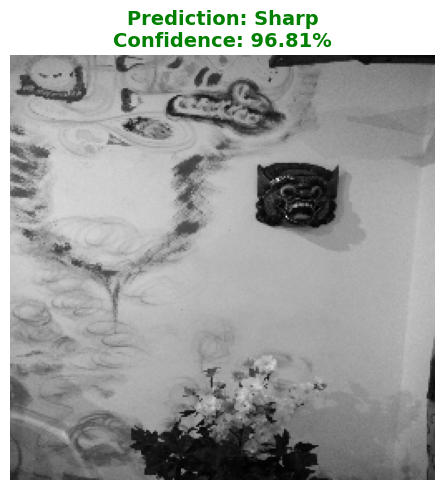


----------------------------------------
Result     : Sharp
Confidence : 96.81%
----------------------------------------

Feature Values:
   Laplacian Var  : 856.4707
   Edge Density   : 0.0659
   Gradient Mean  : 44.7498
   Gradient Std   : 64.7458
   Tenengrad      : 6194.5617
   FFT High Freq  : 0.6223

----------------------------------------
Test Your Own Image
----------------------------------------


Saving blurred2.jpg to blurred2.jpg
Saving blurred3.jpg to blurred3.jpg
Saving crowned_crane_blurred.vs.sharp.jpg to crowned_crane_blurred.vs.sharp.jpg
Saving sharp.jpg to sharp.jpg
Saving sharp_3.jpg to sharp_3.jpg
Saving sharp1.jpg to sharp1.jpg
Saving sharp4.jpg to sharp4.jpg
Saving sharp5.jpg to sharp5.jpg
Saving sharp6.jpg to sharp6.jpg
Saving sharp7.jpg to sharp7.jpg
Saving slightlyblurred1.jpg to slightlyblurred1.jpg

Testing: blurred2.jpg


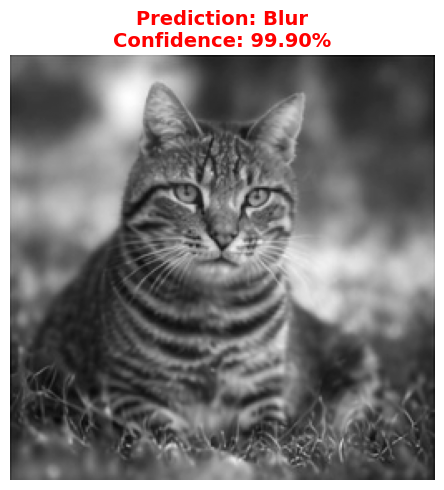


----------------------------------------
Result     : Blur
Confidence : 99.90%
----------------------------------------

Feature Values:
   Laplacian Var  : 332.1264
   Edge Density   : 0.1008
   Gradient Mean  : 59.2745
   Gradient Std   : 58.2924
   Tenengrad      : 6911.4745
   FFT High Freq  : 0.5144

Testing: blurred3.jpg


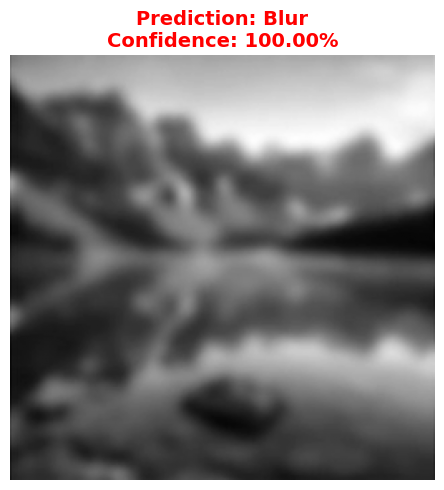


----------------------------------------
Result     : Blur
Confidence : 100.00%
----------------------------------------

Feature Values:
   Laplacian Var  : 7.0224
   Edge Density   : 0.0000
   Gradient Mean  : 23.9976
   Gradient Std   : 18.2453
   Tenengrad      : 908.7785
   FFT High Freq  : 0.2813

Testing: crowned_crane_blurred.vs.sharp.jpg


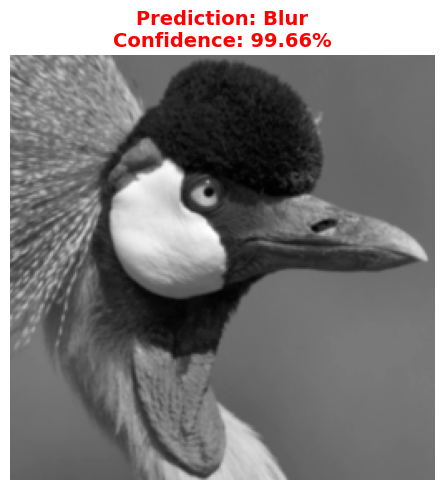


----------------------------------------
Result     : Blur
Confidence : 99.66%
----------------------------------------

Feature Values:
   Laplacian Var  : 184.6929
   Edge Density   : 0.0620
   Gradient Mean  : 39.8278
   Gradient Std   : 57.4750
   Tenengrad      : 4889.6340
   FFT High Freq  : 0.4646

Testing: sharp.jpg


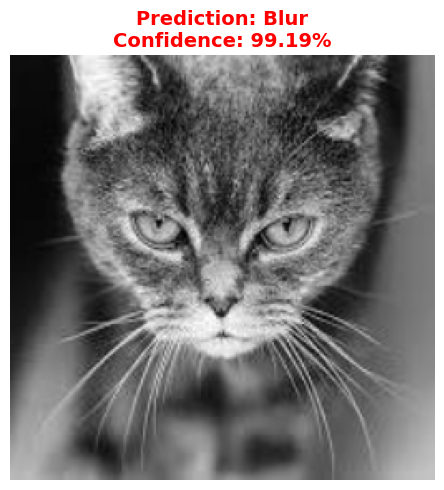


----------------------------------------
Result     : Blur
Confidence : 99.19%
----------------------------------------

Feature Values:
   Laplacian Var  : 979.5565
   Edge Density   : 0.1543
   Gradient Mean  : 77.1979
   Gradient Std   : 78.7165
   Tenengrad      : 12155.7965
   FFT High Freq  : 0.5802

Testing: sharp_3.jpg


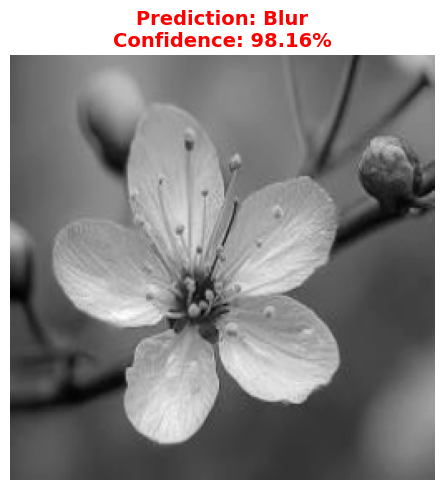


----------------------------------------
Result     : Blur
Confidence : 98.16%
----------------------------------------

Feature Values:
   Laplacian Var  : 250.8368
   Edge Density   : 0.0441
   Gradient Mean  : 38.3453
   Gradient Std   : 58.7377
   Tenengrad      : 4920.4741
   FFT High Freq  : 0.4867

Testing: sharp1.jpg


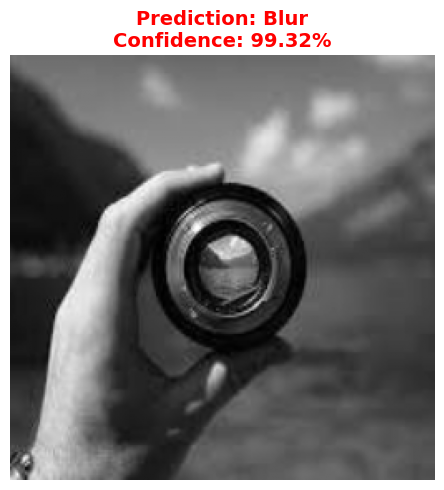


----------------------------------------
Result     : Blur
Confidence : 99.32%
----------------------------------------

Feature Values:
   Laplacian Var  : 208.6161
   Edge Density   : 0.0327
   Gradient Mean  : 37.3194
   Gradient Std   : 66.4533
   Tenengrad      : 5808.7815
   FFT High Freq  : 0.4491

Testing: sharp4.jpg


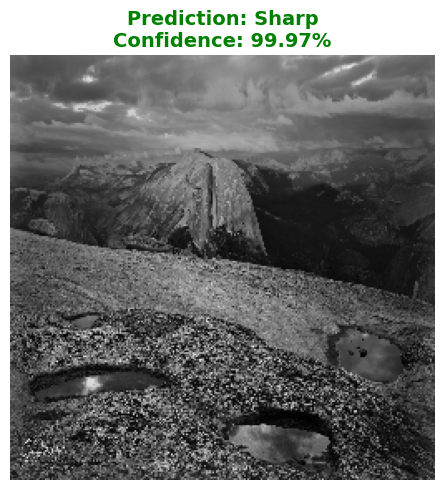


----------------------------------------
Result     : Sharp
Confidence : 99.97%
----------------------------------------

Feature Values:
   Laplacian Var  : 10006.2020
   Edge Density   : 0.1923
   Gradient Mean  : 99.4870
   Gradient Std   : 97.7775
   Tenengrad      : 19458.1004
   FFT High Freq  : 0.8257

Testing: sharp5.jpg


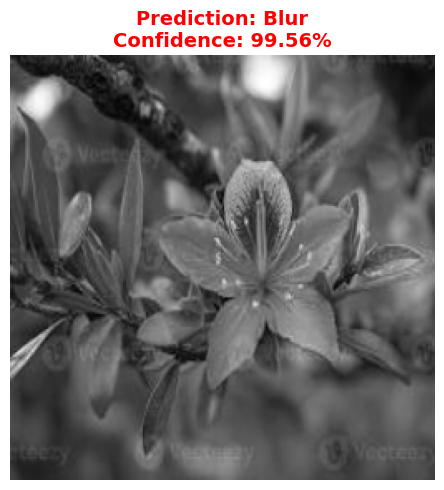


----------------------------------------
Result     : Blur
Confidence : 99.56%
----------------------------------------

Feature Values:
   Laplacian Var  : 324.9470
   Edge Density   : 0.0770
   Gradient Mean  : 55.5704
   Gradient Std   : 57.4926
   Tenengrad      : 6393.4774
   FFT High Freq  : 0.5255

Testing: sharp6.jpg


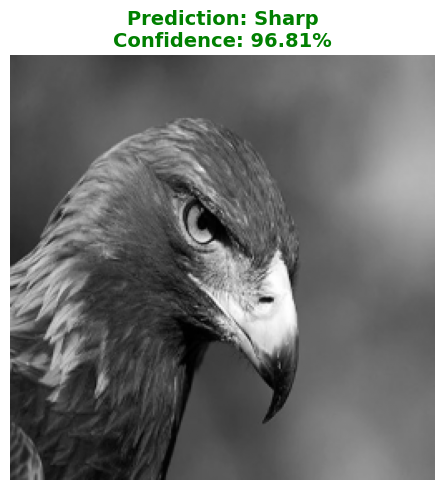


----------------------------------------
Result     : Sharp
Confidence : 96.81%
----------------------------------------

Feature Values:
   Laplacian Var  : 914.5159
   Edge Density   : 0.0854
   Gradient Mean  : 46.8644
   Gradient Std   : 75.7171
   Tenengrad      : 7929.3535
   FFT High Freq  : 0.6151

Testing: sharp7.jpg


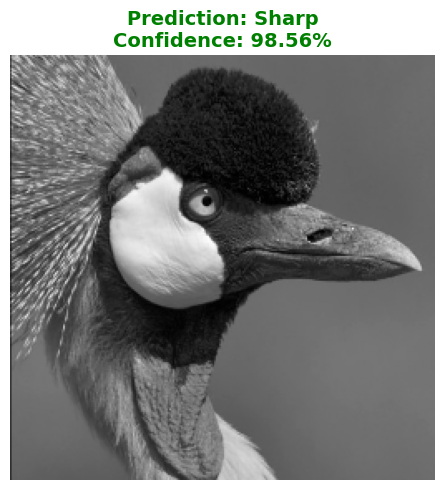


----------------------------------------
Result     : Sharp
Confidence : 98.56%
----------------------------------------

Feature Values:
   Laplacian Var  : 1443.7875
   Edge Density   : 0.0951
   Gradient Mean  : 51.3566
   Gradient Std   : 74.6159
   Tenengrad      : 8205.0252
   FFT High Freq  : 0.6575

Testing: slightlyblurred1.jpg


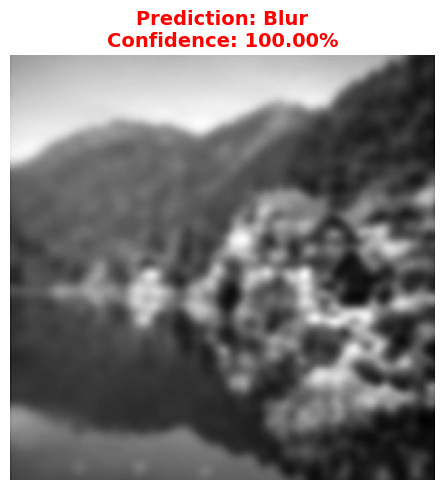


----------------------------------------
Result     : Blur
Confidence : 100.00%
----------------------------------------

Feature Values:
   Laplacian Var  : 14.2413
   Edge Density   : 0.0132
   Gradient Mean  : 34.2574
   Gradient Std   : 34.0274
   Tenengrad      : 2331.4305
   FFT High Freq  : 0.2451


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import joblib
import torch
import cv2
import numpy as np

# ------------------------------
#  Prediction
# ------------------------------
def predict_image(img_path):
    # load img
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Cannot read image!")
        return

    # resize
    img_resized = cv2.resize(img, (256, 256))

    #  Extract features
    features = extract_features(img_resized)

    # normalize
    scaler = joblib.load('scaler.pkl')
    features_scaled = scaler.transform([features])

    # evualuation
    model.eval()
    with torch.no_grad():
        tensor = torch.FloatTensor(features_scaled).to(device)
        output = model(tensor)
        prob   = torch.sigmoid(output).item()

    # result
    label      = "Sharp" if prob > 0.5 else "Blur"
    confidence = prob if prob > 0.5 else 1 - prob
    color      = "green" if label == "Sharp" else "red"

    # visualize the image
    plt.figure(figsize=(6, 5))
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%",
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    #  Features
    feature_names = ['Laplacian Var', 'Edge Density',
                     'Gradient Mean', 'Gradient Std',
                     'Tenengrad',     'FFT High Freq']

    print(f"\n{'-'*40}")
    print(f"Result     : {label}")
    print(f"Confidence : {confidence*100:.2f}%")
    print(f"{'-'*40}")
    print("\nFeature Values:")
    for name, val in zip(feature_names, features):
        print(f"   {name:15s}: {val:.4f}")

    return label, confidence

# ------------------------------------
# Demo based on images from the data
# ------------------------------------
print("Demo - Testing on sample images\n")

#  Blur
blur_sample  = os.path.join(path, 'defocused_blurred',
               os.listdir(os.path.join(path, 'defocused_blurred'))[0])

# Sharp
sharp_sample = os.path.join(path, 'sharp',
               os.listdir(os.path.join(path, 'sharp'))[0])

print("Testing Blur Image:")
predict_image(blur_sample)

print("\nTesting Sharp Image:")
predict_image(sharp_sample)

# ------------------------------
# Demo f0r your image
# -----------------------------
print("\n" + "-"*40)
print("Test Your Own Image")
print("-"*40)

uploaded = files.upload()

for img_name in uploaded.keys():
    print(f"\nTesting: {img_name}")
    predict_image(img_name)